In [ ]:
# Importing System
from MDToolkit.IO.read_file import lammps_dump_file_to_simulation

LAMMPS_dump_file_path = "/media/jrjoseph/Elements/projects/training/water_box_ls6/water_box_nvt_prod.out"

type_mapping = {
    1 : "O",
    2 : "H"
}

water_box_simulation = lammps_dump_file_to_simulation(LAMMPS_dump_file_path, type_mapping)

/oden/jrjoseph/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Reading and Converting Frames: 100%|██████████| 1001/1001 [04:02<00:00,  4.14frame/s]


In [ ]:
import matplotlib.pyplot as plt

def plot_axial_density(
    density_data,
    axis = "x",
    show_std = True,
    std_label = "Std Err",
    ax = None
):
    '''
    '''

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(
        density_data["bin_centers"],
        density_data["density_mean"],
        label = "Density"
    )

    if show_std:

        ax.fill_between(
            density_data["bin_centers"],
            density_data["density_mean"] - density_data["density_std"],
            density_data["density_mean"] + density_data["density_std"],
            alpha = 0.3,
            label = std_label
        )

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Density (g/cm³)")
    ax.legend()

    return ax

def plot_elemental_number_density(
    density_data,
    axis = "x",
    elements = None,
    show_std = True,
    std_label = "Std Err",
    ax = None
):
    '''
    '''

    if ax is None:
        fig, ax = plt.subplots()

    profiles = density_data["elemental_number_density_mean"]

    if elements is None:
        elements = sorted(profiles.keys())

    for element in elements:

        ax.plot(
            density_data["bin_centers"],
            profiles[element],
            label = element
        )

        if show_std:

            std = density_data["elemental_number_density_std"][element]

            ax.fill_between(
                density_data["bin_centers"],
                profiles[element] - std,
                profiles[element] + std,
                alpha = 0.2,
                label = f"{element} {std_label}"
            )

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Normalized Number Density")
    ax.legend()

    return ax

In [ ]:
from MDToolkit.analysis.density import  averaged_axial_density

chosen_axis = "x"

density = averaged_axial_density(water_box_simulation, axis=chosen_axis, bins = 500)

print(density)

{'bin_edges': array([4.39611104e-03, 6.43405266e-02, 1.24284942e-01, 1.84229358e-01,
       2.44173773e-01, 3.04118189e-01, 3.64062604e-01, 4.24007020e-01,
       4.83951435e-01, 5.43895851e-01, 6.03840267e-01, 6.63784682e-01,
       7.23729098e-01, 7.83673513e-01, 8.43617929e-01, 9.03562344e-01,
       9.63506760e-01, 1.02345118e+00, 1.08339559e+00, 1.14334001e+00,
       1.20328442e+00, 1.26322884e+00, 1.32317325e+00, 1.38311767e+00,
       1.44306208e+00, 1.50300650e+00, 1.56295092e+00, 1.62289533e+00,
       1.68283975e+00, 1.74278416e+00, 1.80272858e+00, 1.86267299e+00,
       1.92261741e+00, 1.98256182e+00, 2.04250624e+00, 2.10245066e+00,
       2.16239507e+00, 2.22233949e+00, 2.28228390e+00, 2.34222832e+00,
       2.40217273e+00, 2.46211715e+00, 2.52206156e+00, 2.58200598e+00,
       2.64195040e+00, 2.70189481e+00, 2.76183923e+00, 2.82178364e+00,
       2.88172806e+00, 2.94167247e+00, 3.00161689e+00, 3.06156130e+00,
       3.12150572e+00, 3.18145014e+00, 3.24139455e+00, 3.301338

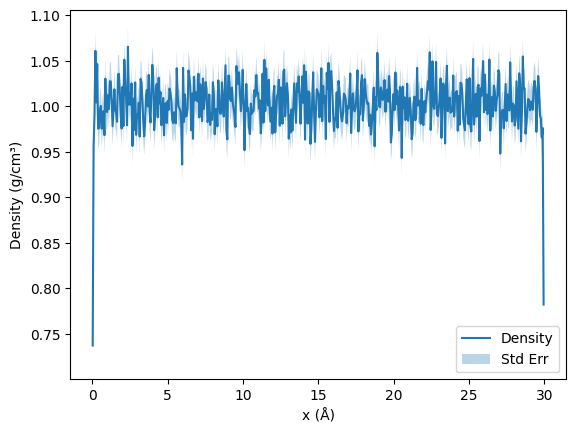

In [ ]:
ax = plot_axial_density(
    density,
    axis = chosen_axis
)

plt.show()

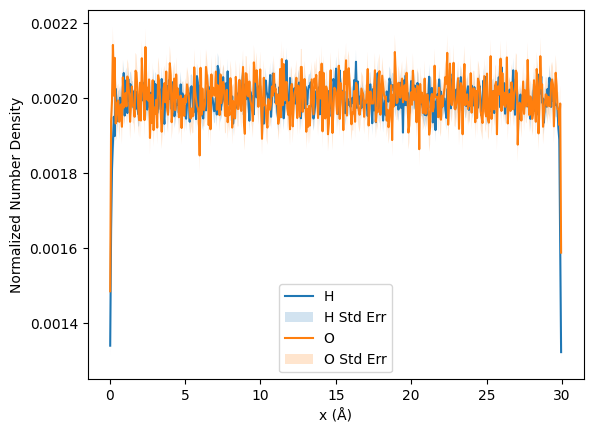

In [ ]:
plot_elemental_number_density(density)
plt.show()